#**TRANSACTION INTELLIGENCE SYSTEM**

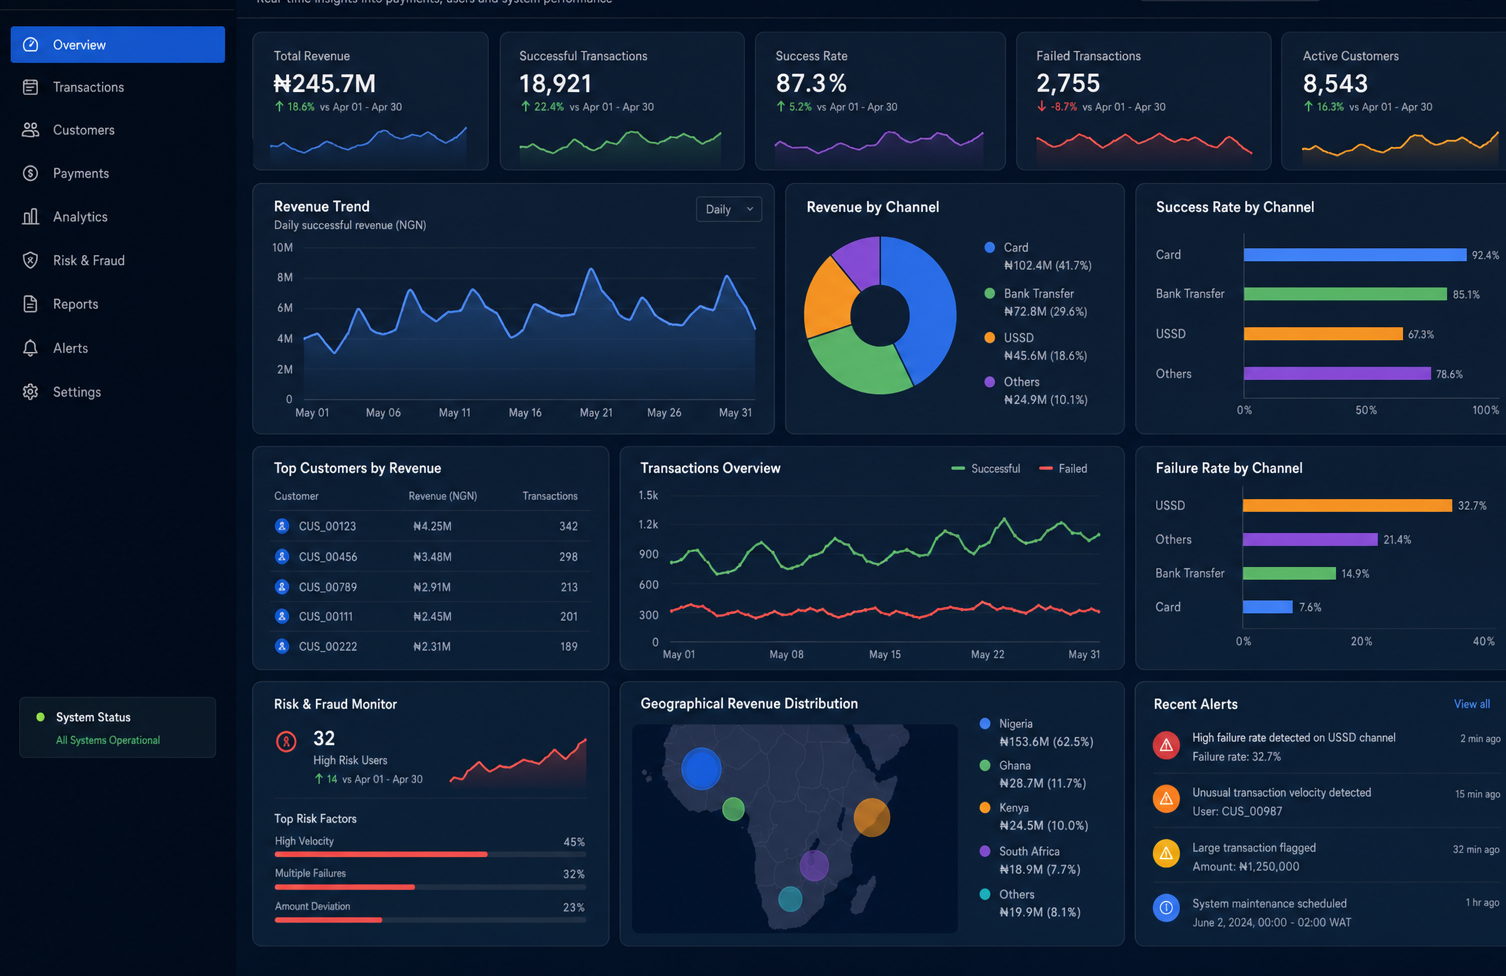

##**OVERVIEW**

This project is an end-to-end transaction intelligence system designed to simulate real-world fintech operations. It analyzes customer transactions to uncover insights related to revenue performance, payment failures, fraud risk, and customer behavior.

Using a structured dataset of 20,000 transactions across multiple payment channels (card, transfer, USSD), the system applies SQL-driven analytics and Python-based visualizations to answer critical business questions such as:

* Where revenue is being lost?
* Which users present potential risk?

The system mirrors real-world fintech workflows by combining data modeling, and analytical querying.

##**DATASET**
This project was carried out using two datasets;


*   Customer
*   Transaction


The customer dataset can be found [here](https://drive.google.com/file/d/1_kXQpR8VcFFPnARPVb9YJh9udgZTHQUn/view?usp=sharing) . This dataset is made up of three columns;
```
Customer_id
Signup Date
Country
```


The transaction dataset can be found [here](https://drive.google.com/file/d/1rs1rpj0Au2VMiadC2xWYdtwtF85sHrZu/view?usp=sharing). This dataset is made up of six columns;
```
Transaction_id
Customer_id
Amount
Status (Success/Failed)
Channel (Card/Transfer/USSD)
Transaction_date
```




###**Import Libraries**

In [80]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

In [81]:
# load dataset
Customers = pd.read_csv("customers.csv")
Transactions = pd.read_csv("transactions (1).csv")

In [82]:
Customers.shape

(2000, 3)

The customers dataset has **2000** rows & **3** columns

In [83]:
Transactions.shape

(20000, 6)

The transactions dataset has **20000** rows & **6** columns

In [84]:
Customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  2000 non-null   int64 
 1   signup_date  2000 non-null   object
 2   country      2000 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB


In [85]:
Transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    20000 non-null  int64  
 1   customer_id       20000 non-null  int64  
 2   amount            20000 non-null  float64
 3   status            20000 non-null  object 
 4   channel           20000 non-null  object 
 5   transaction_date  20000 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 937.6+ KB


In [86]:
# checking for missing values
Customers.sum().isnull()

,0
customer_id,False
signup_date,False
country,False


In [87]:
# checking for missing values
Transactions.sum().isnull()

,0
transaction_id,False
customer_id,False
amount,False
status,False
channel,False
transaction_date,False


In [88]:
# checking for duplicates
Transactions.duplicated().sum()

np.int64(0)

In [89]:
# checking for duplicates
Customers.duplicated().sum()

np.int64(0)

From the above, there are no suplicates and no missing values in both datasets.

###**Connect To Sqlite**

In [90]:
conn = sqlite3.connect("Fin.db")

###**Push DataFrame Into SQL**

In [91]:
# customer table
Customers.to_sql(
    "Customers",            # table name
    conn,                   # connection
    if_exists = "replace",  # if table exists, replace it
    index = False           #don't save pandas index
)

2000

In [92]:
# transaction table
Transactions.to_sql(
    "Transactions",
    conn,
    if_exists = "replace",
    index = False
)

20000

##**REVENUE ANALYTICS**

###**Total Revenue**

In [93]:
query = ("""
SELECT SUM(amount) AS Total_revenue
FROM Transactions
WHERE status = "success"
""");
pd.read_sql(query, conn)

,Total_revenue
0,91077461.92


###**Daily revenue**

In [94]:
query = ("""
SELECT DATE(transaction_date) AS Day, SUM(amount) AS Daily_revenue
FROM Transactions
WHERE status = "success"
GROUP BY Day
""");
pd.read_sql(query, conn)

,Day,Daily_revenue
0,2024-01-01,917587.79
1,2024-01-02,791766.50
2,2024-01-03,704671.76
3,2024-01-04,751171.72
4,2024-01-05,752698.75
...,...,...
115,2024-04-25,855727.61
116,2024-04-26,663814.27
117,2024-04-27,785498.93
118,2024-04-28,816033.93


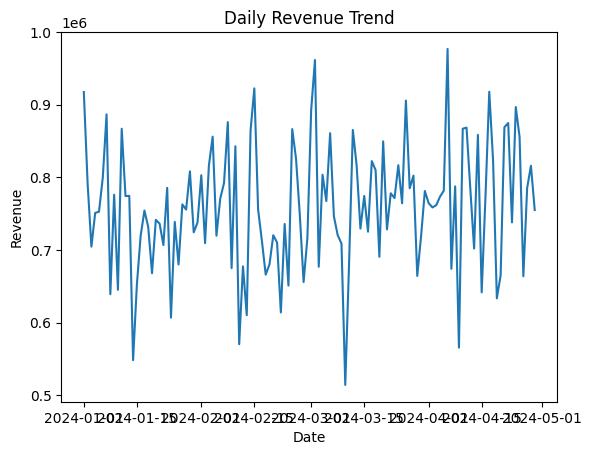

In [95]:
# visual

#convert transaction_date into a real datetime format
Trans = pd.read_csv("transactions (1).csv", parse_dates = ["transaction_date"])
Daily = Trans[Trans["status"] == "success"].groupby(Trans["transaction_date"].dt.date)["amount"].sum()

plt.figure()
Daily.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

###**Monthly Revenue**

In [96]:
query = ("""
SELECT
    strftime("%Y-%m", transaction_date) AS Months,
    SUM(amount) AS Monthly_revenue
FROM Transactions
WHERE status = "success"
GROUP BY Months
""");
pd.read_sql(query, conn)

,Months,Monthly_revenue
0,2024-01,22940302.89
1,2024-02,21566045.99
2,2024-03,23935291.95
3,2024-04,22635821.09


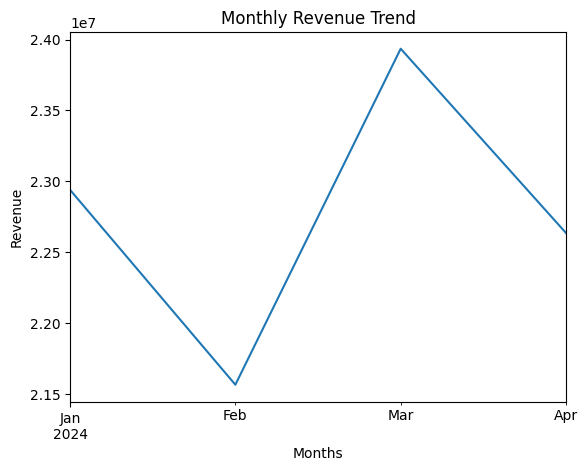

In [97]:
# visual
Monthly= Trans[Trans["status"] == "success"].groupby(Trans["transaction_date"].dt.to_period("M"))["amount"].sum()

plt.figure()
Monthly.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.show()

###**Revenue By Channel**

In [98]:
query = ("""
SELECT channel, SUM(amount) AS Total_revenue
FROM Transactions
WHERE status = "success"
GROUP BY channel
""");
pd.read_sql(query, conn)

,channel,Total_revenue
0,card,30503286.95
1,transfer,30509263.05
2,ussd,30064911.92


###**Leakage Rate Per Channel**

In [99]:
query = ("""
SELECT
  channel,
  SUM(amount) AS Attempted_revenue,
  SUM(CASE WHEN status='success' THEN amount END) AS Successful_revenue,
  SUM(CASE WHEN status='failed' THEN amount END) AS Failed_revenue,
  SUM(CASE WHEN status='failed' THEN amount END) * 1.0 / SUM(amount) AS Leakage_rate
FROM Transactions
GROUP BY channel
""");
pd.read_sql(query, conn)

,channel,Attempted_revenue,Successful_revenue,Failed_revenue,Leakage_rate
0,card,33828836.64,30503286.95,3325549.69,0.098305
1,transfer,33786591.36,30509263.05,3277328.31,0.097001
2,ussd,33169802.96,30064911.92,3104891.04,0.093606


###**Top 10 Revenue Days**

In [100]:
query =("""
SELECT strftime("%Y-%m-%d", transaction_date) AS Day, SUM(amount) AS Revenue
FROM Transactions
WHERE status = "success"
GROUP BY Day
ORDER BY Revenue DESC
LIMIT 10
""");
pd.read_sql(query, conn)

,Day,Revenue
0,2024-04-06,976922.58
1,2024-03-02,961670.76
2,2024-02-15,922574.60
3,2024-04-17,917943.57
4,2024-01-01,917587.79
5,2024-03-26,905769.28
6,2024-04-24,896880.25
7,2024-03-01,892696.34
8,2024-01-07,886809.80
9,2024-02-08,876105.89


###**Average Transaction Value**


In [101]:
query = ("""
SELECT AVG(amount) AS Avg_Transaction
FROM Transactions
WHERE status = "success"
""");
pd.read_sql(query, conn)

,Avg_Transaction
0,5053.1215


###**Revenue Per Customer**

In [102]:
query = ("""
SELECT customer_id, SUM(amount) AS Total_revenue
FROM Transactions
WHERE status = "success"
GROUP BY customer_id
""");
pd.read_sql(query, conn)

,customer_id,Total_revenue
0,1,58343.61
1,2,11567.44
2,3,48376.10
3,4,18730.52
4,5,15487.67
...,...,...
1995,1996,24019.82
1996,1997,64639.77
1997,1998,16543.09
1998,1999,39401.90


###**Revenue Contribution By Top 5% Users**

In [103]:
query = ("""
WITH Ranked AS (
  SELECT customer_id,
         SUM(amount) AS Total_revenue,
         NTILE(20) OVER (ORDER BY SUM(amount) DESC) AS bucket
  FROM Transactions
  WHERE status = "success"
  GROUP BY customer_id
)
SELECT SUM(Total_revenue)
FROM Ranked
WHERE bucket = 1
""");
pd.read_sql(query, conn)

,SUM(Total_revenue)
0,9812853.65


###**Top 5% Users**

In [104]:
query = ("""
WITH Ranked AS (
  SELECT customer_id,
         SUM(amount) AS Total_Revenue,
         NTILE(20) OVER (ORDER BY SUM(amount) DESC) AS Bucket
  FROM Transactions
  WHERE status = "success"
  GROUP BY customer_id
)
SELECT customer_id, Total_revenue
FROM Ranked
WHERE Bucket = 1
""");
pd.read_sql(query, conn)

,customer_id,Total_Revenue
0,1154,151283.56
1,899,147825.15
2,1938,136580.49
3,1302,126450.62
4,528,125670.82
...,...,...
95,1292,85771.26
96,85,85573.31
97,663,85346.22
98,95,85324.55


###**Top 5 Of The Top 5%**

In [105]:
query = ("""
WITH Ranked AS (
  SELECT customer_id,
         SUM(amount) AS Total_Revenue,
         NTILE(20) OVER (ORDER BY SUM(amount) DESC) AS Bucket
  FROM Transactions
  WHERE status = "success"
  GROUP BY customer_id
)
SELECT customer_id, Total_revenue
FROM Ranked
WHERE Bucket = 1
ORDER BY Total_revenue DESC
LIMIT 5
""");
pd.read_sql(query, conn)

,customer_id,Total_Revenue
0,1154,151283.56
1,899,147825.15
2,1938,136580.49
3,1302,126450.62
4,528,125670.82


###**Least 2% Users**

In [106]:
query = ("""
WITH Ranked AS(
  SELECT customer_id,
         SUM(amount) AS Total_Revenue,
         NTILE(50) OVER (ORDER BY SUM(amount) DESC) AS Bucket
  FROM Transactions
  WHERE status = "success"
  GROUP BY customer_id
)
SELECT customer_id,
       Total_revenue
FROM Ranked
WHERE Bucket = 50
""");
pd.read_sql(query, conn)

,customer_id,Total_Revenue
0,952,8988.81
1,89,8960.46
2,1833,8737.55
3,1570,8584.13
4,437,8463.31
5,190,8420.84
6,451,8419.86
7,1221,8344.48
8,1800,8248.38
9,1020,8130.25


###**Revenue Contributed By Least 2% Users**

In [107]:
query = ("""
WITH Ranked AS (
  SELECT customer_id,
         SUM(amount) AS Total_revenue,
         NTILE(50) OVER (ORDER BY SUM(amount) DESC) AS Bucket
  FROM Transactions
  WHERE status = "success"
  GROUP BY customer_id
)
SELECT SUM(Total_revenue)
FROM Ranked
WHERE Bucket = 50
""");
pd.read_sql(query, conn)

,SUM(Total_revenue)
0,259075.99


###**Revenue Growth Rate**



In [108]:
query =("""
SELECT Months,
       Total_revenue,
       LAG(Total_revenue) OVER (ORDER BY Months) AS Previous_revenue,
       (Total_revenue - LAG(Total_revenue) OVER (ORDER BY Months))
       / LAG(Total_revenue) OVER (ORDER BY Months) AS Growth_rate
FROM
  (SELECT strftime("%Y-%m", transaction_date) AS Months,
        SUM(amount) AS Total_revenue
  FROM Transactions
  WHERE status = "success"
  GROUP BY Months)
""");
pd.read_sql(query, conn)

,Months,Total_revenue,Previous_revenue,Growth_rate
0,2024-01,22940302.89,NaN,NaN
1,2024-02,21566045.99,22940302.89,-0.059906
2,2024-03,23935291.95,21566045.99,0.109860
3,2024-04,22635821.09,23935291.95,-0.054291




*   February dropped by 5.9%
*   March grew by 10%
*   April dropped by 5.4%



###**Attempted vs successful Revenue**

In [109]:
query = ("""
SELECT
  SUM(amount) AS Attempted_revenue,
  SUM(CASE WHEN status='success' THEN amount END) AS Successful_revenue,
  SUM(CASE WHEN status='failed' THEN amount END) AS Failed_revenue,
  SUM(CASE WHEN status='failed' THEN amount END) * 1.0 / SUM(amount) AS Leakage_rate
FROM Transactions
""");
pd.read_sql(query, conn)

,Attempted_revenue,Successful_revenue,Failed_revenue,Leakage_rate
0,1.007852e+08,91077461.92,9707769.04,0.096321


Leakage Rate is 9.6%

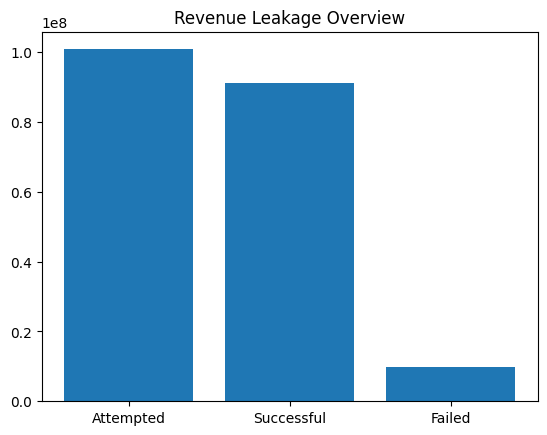

In [110]:
# visual
summary = {
    "Attempted": Trans["amount"].sum(),
    "Successful": Trans[Trans["status"]=="success"]["amount"].sum(),
    "Failed": Trans[Trans["status"]=="failed"]["amount"].sum()
}

plt.figure()
plt.bar(summary.keys(), summary.values())
plt.title("Revenue Leakage Overview")
plt.show()

##**CUSTOMER BEHAVIOUR**

###**Total Customers**

In [111]:
query = ("""
SELECT COUNT(DISTINCT customer_id) AS consumers
FROM Customers
""");
pd.read_sql(query, conn)

,consumers
0,2000


###**Top 10 Customers**

In [112]:
query = ("""
SELECT customer_id,
       SUM(amount) AS Total_amount
FROM Transactions
GROUP BY customer_id
ORDER BY Total_amount DESC
LIMIT 10
""");
pd.read_sql(query, conn)

,customer_id,Total_amount
0,1154,152361.15
1,899,147825.15
2,1938,136580.49
3,13,134870.14
4,528,132369.51
5,1630,128432.28
6,1564,126544.98
7,1302,126450.62
8,948,124644.12
9,1097,123439.29


###**New Customers Per Month**

In [113]:
query=("""
SELECT strftime("%Y-%m", signup_date) AS Date, COUNT(*)
FROM Customers
GROUP BY 1
""");
pd.read_sql(query, conn)

,Date,COUNT(*)
0,2023-01,179
1,2023-02,162
2,2023-03,141
3,2023-04,170
4,2023-05,167
5,2023-06,178
6,2023-07,142
7,2023-08,196
8,2023-09,156
9,2023-10,170


###**Transactions Per Customer**

In [114]:
query = ("""
SELECT customer_id,
       COUNT(*)
FROM Transactions
GROUP BY customer_id
""");
pd.read_sql(query, conn)

,customer_id,COUNT(*)
0,1,11
1,2,3
2,3,8
3,4,6
4,5,6
...,...,...
1995,1996,5
1996,1997,10
1997,1998,6
1998,1999,8


###**Average Transactions Per User**

In [115]:
query = ("""
SELECT AVG(Txn_count)
FROM
  (SELECT customer_id,
          COUNT(*) AS Txn_count
  FROM Transactions
  GROUP BY customer_id)
""");
pd.read_sql(query, conn)

,AVG(Txn_count)
0,10.0


###**Total_revenue Per Customer**

In [116]:
query = ("""
SELECT customer_id,
       SUM(amount) AS Total
FROM Transactions
WHERE status = "success"
GROUP BY customer_id
""");
pd.read_sql(query, conn)

,customer_id,Total
0,1,58343.61
1,2,11567.44
2,3,48376.10
3,4,18730.52
4,5,15487.67
...,...,...
1995,1996,24019.82
1996,1997,64639.77
1997,1998,16543.09
1998,1999,39401.90


###**High-Value Customers (>100k Total Spent)**

In [117]:
query = ("""
SELECT customer_id, SUM(amount) AS Total_spent
FROM Transactions
WHERE status = "success"
GROUP BY customer_id
HAVING Total_spent > 100000
""");
pd.read_sql(query, conn)

,customer_id,Total_spent
0,13,106797.58
1,112,112082.82
2,123,100864.58
3,283,115069.05
4,387,103960.50
5,429,116029.95
6,446,118986.17
7,455,111836.96
8,528,125670.82
9,606,101047.28


###**Top 10 Customers by Lifetime Value**

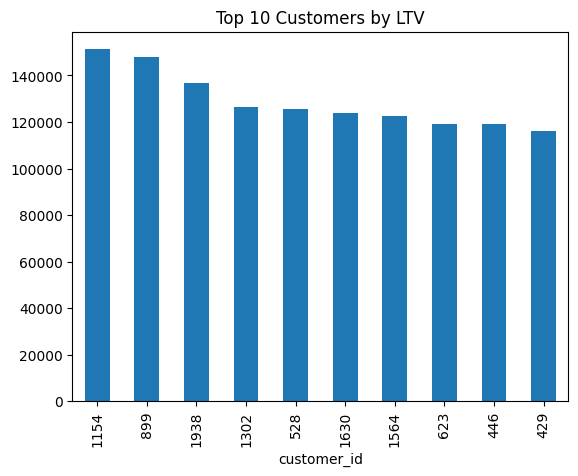

In [118]:
# lifetime Value
Ltv = Trans[Trans["status"]=="success"].groupby("customer_id")["amount"].sum().sort_values(ascending=False).head(10)

plt.figure()
Ltv.plot(kind="bar")
plt.title("Top 10 Customers by LTV")
plt.show()

###**Customer Segmentation**

In [119]:
query =("""
SELECT customer_id,
CASE
  WHEN SUM(amount) > 100000 THEN "High"
  WHEN SUM(amount) > 50000 THEN "Medium"
  ELSE "Low"
END AS Segment
FROM Transactions
GROUP BY customer_id
""");
pd.read_sql(query, conn)

,customer_id,Segment
0,1,Medium
1,2,Low
2,3,Medium
3,4,Low
4,5,Low
...,...,...
1995,1996,Low
1996,1997,Medium
1997,1998,Low
1998,1999,Low


###**Most Active Country**

In [120]:
query=("""
SELECT c.country, COUNT(*)
FROM Transactions t
JOIN Customers c USING(customer_id)
GROUP BY c.country
ORDER BY COUNT(*) DESC
""");
pd.read_sql(query, conn)

,country,COUNT(*)
0,Nigeria,6873
1,Ghana,6669
2,Kenya,6458


In [121]:
query = ("""
SELECT c.country, COUNT(*)
FROM Customers c
LEFT JOIN Transactions t
ON c.customer_id = t.customer_id
GROUP BY c.country
ORDER BY COUNT(*) DESC
""");
pd.read_sql(query, conn)

,country,COUNT(*)
0,Nigeria,6873
1,Ghana,6669
2,Kenya,6458


###**First Transaction Date Per Customer**

In [122]:
query=("""
SELECT customer_id,
       MIN(transaction_date) AS First_txn
FROM Transactions
GROUP BY customer_id
""");
pd.read_sql(query, conn)

,customer_id,First_txn
0,1,2024-01-06
1,2,2024-01-30
2,3,2024-01-07
3,4,2024-01-18
4,5,2024-01-26
...,...,...
1995,1996,2024-01-23
1996,1997,2024-01-07
1997,1998,2024-01-13
1998,1999,2024-01-11


###**Transaction Distribution**

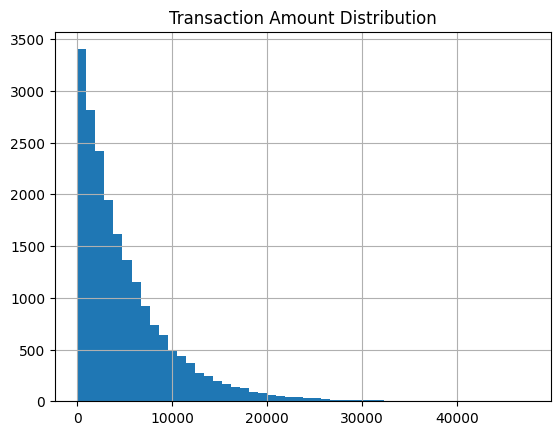

In [123]:
plt.figure()
Trans["amount"].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

##**FAILURE & RETRY**

###**Number of Failed Transactions**

In [124]:
query = ("""
SELECT COUNT(*) AS Failed_txn
FROM Transactions
WHERE status = "failed"
""");
pd.read_sql(query, conn)

,Failed_txn
0,1976


###**Failure Rate**

In [125]:
query =("""
SELECT
COUNT(*)
FILTER (WHERE status = "failed") * 1.0 / COUNT(*) AS Failure_rate
FROM Transactions
""");
pd.read_sql(query, conn)

,Failure_rate
0,0.0988


###**Failure Rate Per Channel**

In [126]:
query = ("""
SELECT channel,
COUNT(*)
FILTER (WHERE status = "failed") * 1.0 / COUNT(*) AS Failure_rate
FROM Transactions
GROUP BY channel
""");
pd.read_sql(query, conn)

,channel,Failure_rate
0,card,0.100644
1,transfer,0.101322
2,ussd,0.094357


/tmp/ipykernel_139/823476473.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Failure = Trans.groupby("channel").apply(


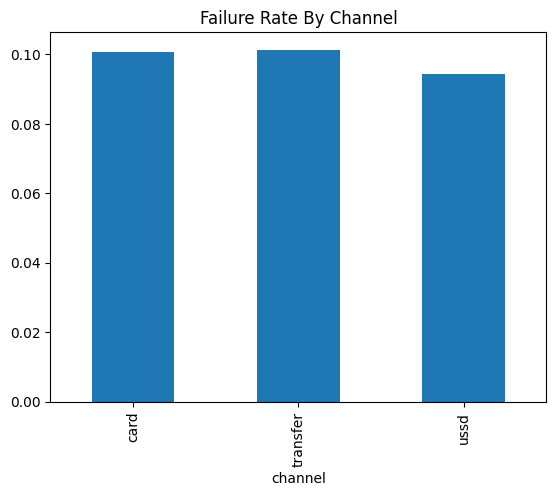

In [127]:
# visual
Failure = Trans.groupby("channel").apply(
    lambda x: (x["status"] == "failed").mean()
)
plt.figure()
Failure.plot(kind = "bar")
plt.title("Failure Rate By Channel")
plt.show()

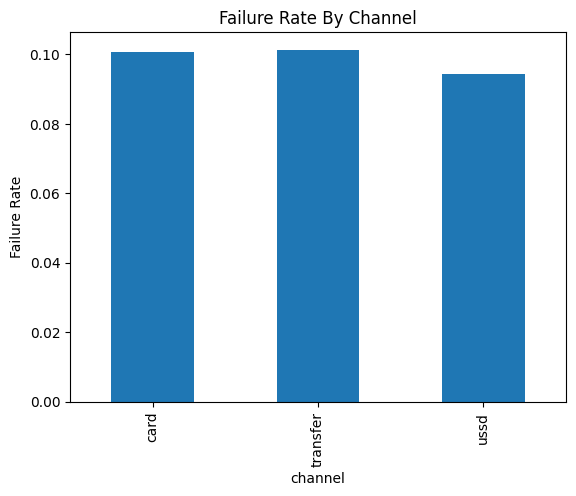

In [128]:
Failure = (
    Trans.assign(is_failed=Trans["status"] == "failed")
    .groupby("channel")["is_failed"]
    .mean()
)

plt.figure()
Failure.plot(kind="bar")
plt.title("Failure Rate By Channel")
plt.ylabel("Failure Rate")
plt.show()

###**Customers With Failed Transactions**

In [129]:
query = ("""
SELECT DISTINCT customer_id
FROM Transactions
WHERE status = "failed"
""");
pd.read_sql(query, conn)

,customer_id
0,1762
1,1597
2,1318
3,1259
4,331
...,...
1227,1324
1228,826
1229,309
1230,102


###**Failed Transactions Per Customer**

In [130]:
query = ("""
SELECT customer_id,
COUNT(*)
FROM Transactions
WHERE status = "failed"
GROUP BY customer_id
""");
pd.read_sql(query, conn)

,customer_id,COUNT(*)
0,3,1
1,8,2
2,9,1
3,10,2
4,13,3
...,...,...
1227,1995,3
1228,1996,1
1229,1997,3
1230,1998,1


###**Retry Behaviour**

In [131]:
query = ("""
SELECT customer_id,
COUNT(*)
FROM Transactions
WHERE status = "failed"
GROUP BY customer_id
HAVING COUNT(*) > 1
""");
pd.read_sql(query, conn)

,customer_id,COUNT(*)
0,8,2
1,10,2
2,13,3
3,16,2
4,17,2
...,...,...
537,1988,2
538,1993,2
539,1995,3
540,1997,3


###**Success After Failure**

In [132]:
query = ("""
SELECT t1.customer_id,
       t1.transaction_date AS Failed_date,
       t2.transaction_date AS Success_date
FROM Transactions t1
JOIN Transactions t2
ON t1.customer_id = t2.customer_id
WHERE t1.status = "failed" AND t2.status = "success"
AND t2.transaction_date > t1.transaction_date
""");
pd.read_sql(query, conn)

,customer_id,Failed_date,Success_date
0,1762,2024-01-21,2024-02-04
1,1762,2024-01-21,2024-02-12
2,1762,2024-01-21,2024-02-25
3,1762,2024-01-21,2024-03-05
4,1762,2024-01-21,2024-03-12
...,...,...,...
8701,1027,2024-01-16,2024-04-18
8702,1027,2024-01-16,2024-04-24
8703,1027,2024-01-16,2024-04-24
8704,1027,2024-01-16,2024-04-25


###**Success After Failure On Same Day**

In [133]:
query = ("""
SELECT t1.customer_id,
       t1.transaction_date AS Failed_date,
       t2.transaction_date AS Success_date
FROM Transactions t1
JOIN Transactions t2
ON t1.customer_id = t2.customer_id
WHERE t1.status = "failed" AND t2.status = "success"
AND t2.transaction_date = t1.transaction_date
""");
pd.read_sql(query, conn)

,customer_id,Failed_date,Success_date
0,1597,2024-02-08,2024-02-08
1,1318,2024-02-26,2024-02-26
2,1318,2024-02-26,2024-02-26
3,1165,2024-04-20,2024-04-20
4,1572,2024-01-25,2024-01-25
...,...,...,...
150,1606,2024-04-08,2024-04-08
151,835,2024-01-12,2024-01-12
152,585,2024-04-06,2024-04-06
153,1592,2024-03-17,2024-03-17


###**Successful vs Failed Transactions Per Customer**

In [134]:
query = ("""
SELECT
    customer_id,
    COUNT(*) AS Total_transactions,
    SUM(CASE WHEN status = 'failed' THEN 1 ELSE 0 END) AS Failed_transactions,
    SUM(CASE WHEN status = 'success' THEN 1 ELSE 0 END) AS Successful_transactions
FROM Transactions
GROUP BY customer_id
ORDER BY customer_id
LIMIT 10
""");
pd.read_sql(query, conn)

,customer_id,Total_transactions,Failed_transactions,Successful_transactions
0,1,11,0,11
1,2,3,0,3
2,3,8,1,7
3,4,6,0,6
4,5,6,0,6
5,6,8,0,8
6,7,7,0,7
7,8,10,2,8
8,9,10,1,9
9,10,9,2,7


###**Failure Spikes By Day**

In [135]:
query = ("""
SELECT strftime("%Y-%m-%d", transaction_date) AS Day,
       COUNT(*) AS Failed_txn
FROM Transactions
WHERE status = "failed"
GROUP BY Day
ORDER BY Failed_txn DESC
LIMIT 5
""");
pd.read_sql(query, conn)

,Day,Failed_txn
0,2024-03-06,26
1,2024-03-15,24
2,2024-01-30,24
3,2024-04-23,23
4,2024-04-13,22


###**Channel With Highest Failures**

In [136]:
query=("""
SELECT channel,
COUNT(*) AS Count
FROM Transactions
WHERE status = "failed"
GROUP BY channel
ORDER BY Count DESC
LIMIT 1
""");
pd.read_sql(query, conn)

,channel,Count
0,transfer,682


###**Failed Amount Lost**

In [137]:
query = ("""
SELECT
SUM(amount)
FROM Transactions
WHERE status = "failed"
""");
pd.read_sql(query, conn)

,SUM(amount)
0,9707769.04


###**% Recovered Revenue (Fail -> Sucess)**

In [138]:
query = ("""
SELECT
SUM(CASE WHEN status = "success" THEN amount END) /
SUM(amount) AS Revenue_rate
FROM Transactions
""");
pd.read_sql(query, conn)

,Revenue_rate
0,0.903679


##**RETENTION & COHORTS**

###**Cohort By Signup Month**

In [139]:
query = ("""
SELECT strftime("%Y-%m", signup_date) AS Months,
COUNT(*) AS Count
FROM Customers
GROUP BY 1
""");
pd.read_sql(query, conn)

,Months,Count
0,2023-01,179
1,2023-02,162
2,2023-03,141
3,2023-04,170
4,2023-05,167
5,2023-06,178
6,2023-07,142
7,2023-08,196
8,2023-09,156
9,2023-10,170


###**Retention (Month 1 Activity)**

Customers still transacting even after 30 days of signing up

In [140]:
query = ("""
SELECT DISTINCT c.customer_id
FROM Customers c
JOIN Transactions t
ON c.customer_id = t.customer_id
WHERE t.transaction_date > DATE(c.signup_date, "+30 days")
""");
pd.read_sql(query, conn)

,customer_id
0,1
1,2
2,3
3,4
4,5
...,...
1995,1996
1996,1997
1997,1998
1998,1999


###**Returning Users**

In [141]:
query = ("""
SELECT customer_id,
COUNT(*) AS Count
FROM Transactions
GROUP BY customer_id
HAVING Count > 1
""");
pd.read_sql(query, conn)

,customer_id,Count
0,1,11
1,2,3
2,3,8
3,4,6
4,5,6
...,...,...
1994,1996,5
1995,1997,10
1996,1998,6
1997,1999,8


###**Churned Users**

Customers who have never made any transactions.

In [142]:
query = ("""
SELECT customer_id
FROM Customers
WHERE customer_id NOT IN(
  SELECT DISTINCT customer_id
  FROM Transactions
)
""");
pd.read_sql(query, conn)

,customer_id


###**Repeat Purchase Rate**

In [143]:
query = ("""
SELECT
COUNT(*) FILTER (WHERE txn_count > 1) * 1.0 / COUNT(*) AS Rate
FROM (
  SELECT customer_id, COUNT(*) txn_count
  FROM Transactions
  GROUP BY customer_id
)
""");
pd.read_sql(query, conn)

,Rate
0,0.9995


###**Average Days Between Transactions**

In [144]:
query =("""
WITH gaps AS (
    SELECT
        customer_id,
        julianday(transaction_date) -
        julianday(
            LAG(transaction_date) OVER (
                PARTITION BY customer_id
                ORDER BY transaction_date
            )
        ) AS gap_days
    FROM transactions
)

SELECT
    customer_id,
    AVG(gap_days) AS avg_days_between_transactions
FROM gaps
GROUP BY customer_id
ORDER BY customer_id
""");
pd.read_sql(query, conn)

,customer_id,avg_days_between_transactions
0,1,9.700000
1,2,36.500000
2,3,12.857143
3,4,18.200000
4,5,16.600000
...,...,...
1995,1996,22.750000
1996,1997,11.444444
1997,1998,18.400000
1998,1999,12.571429


In [145]:
query =("""
WITH gaps AS (
    SELECT
        customer_id,
        julianday(transaction_date) -
        julianday(
            LAG(transaction_date) OVER (
                PARTITION BY customer_id
                ORDER BY transaction_date
            )
        ) AS gap_days
    FROM transactions
)

SELECT
    customer_id,
    ROUND(AVG(gap_days), 0) AS avg_days_between_transactions
FROM gaps
GROUP BY customer_id
ORDER BY customer_id
""");
pd.read_sql(query, conn)

,customer_id,avg_days_between_transactions
0,1,10.0
1,2,37.0
2,3,13.0
3,4,18.0
4,5,17.0
...,...,...
1995,1996,23.0
1996,1997,11.0
1997,1998,18.0
1998,1999,13.0


###**First vs Last Transaction Gap**

In [146]:
query = ("""
SELECT customer_id,
       julianday(MAX(transaction_date)) -
       julianday(MIN(transaction_date)) AS Txn_gap
FROM Transactions
GROUP BY customer_id
""")
pd.read_sql(query, conn)

,customer_id,Txn_gap
0,1,97.0
1,2,73.0
2,3,90.0
3,4,91.0
4,5,83.0
...,...,...
1995,1996,91.0
1996,1997,103.0
1997,1998,92.0
1998,1999,88.0


###**Number of Active Users Per Day**

In [147]:
query = ("""
SELECT strftime("%Y-%m-%d", transaction_date) AS Day,
COUNT(DISTINCT(customer_id))
FROM Transactions
GROUP BY Day
""");
pd.read_sql(query, conn)

,Day,COUNT(DISTINCT(customer_id))
0,2024-01-01,186
1,2024-01-02,156
2,2024-01-03,152
3,2024-01-04,152
4,2024-01-05,158
...,...,...
115,2024-04-25,150
116,2024-04-26,168
117,2024-04-27,172
118,2024-04-28,165


###**Revenue Per Cohort**

In [148]:
query = ("""
SELECT strftime("%Y-%m", c.signup_date) AS Cohorts,
SUM(t.amount) AS Revenue
FROM Customers c
JOIN Transactions t
ON c.customer_id = t.customer_id
WHERE status = "success"
GROUP BY Cohorts
""");
pd.read_sql(query, conn)

,Cohorts,Revenue
0,2023-01,8172729.99
1,2023-02,7587053.67
2,2023-03,6565578.14
3,2023-04,7728880.85
4,2023-05,8321227.07
5,2023-06,8133028.24
6,2023-07,6236253.17
7,2023-08,8899100.96
8,2023-09,7317807.33
9,2023-10,7470241.78


##**CONCLUSION**

The Transaction Intelligence System demonstrates how data can directly drive financial and operational decisions in a fintech environment.

Key conclusions:

* Revenue loss is not random.
* Success rates are controllable, through better routing, retries, and infrastructure improvements.

By aligning data analysis with business outcomes, this project highlights how fintech companies can Improve customer experience and retention